# 06 - Comparaison finale et décision

## Introduction

Dans cette dernière étape du projet **Employee Attrition Prediction - RH**, l'objectif est de comparer les performances des modèles déjà entraînés et de choisir le modèle le plus adapté pour prédire l'attrition des employés.

Ce notebook ne réentraîne aucun modèle. Il charge uniquement les fichiers de métriques sauvegardés dans le dossier `results/metrics`, puis compare les modèles selon l'accuracy, la precision, le recall et le F1-score.

## 1. Importation des bibliothèques

In [18]:
import os

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [19]:
sns.set_theme(style="whitegrid", palette="Set2")
plt.rcParams["figure.figsize"] = (10, 6)

**Interprétation :** Ces bibliothèques permettent de charger les fichiers CSV de métriques, de manipuler les tableaux et de créer les graphiques de comparaison.

## 2. Chargement des fichiers de métriques

In [20]:
metrics_dir = "../results/metrics"

metrics_files = [
    "decision_tree_metrics.csv",
    "decision_tree_improved_metrics.csv",
    "random_forest_baseline_metrics.csv",
    "random_forest_improved_metrics.csv",
    "svm_baseline_metrics.csv",
    "svm_improved_metrics.csv",
]

available_metrics = []
loaded_files = []

for file_name in metrics_files:
    file_path = os.path.join(metrics_dir, file_name)
    if os.path.exists(file_path):
        available_metrics.append(pd.read_csv(file_path))
        loaded_files.append(file_name)

print("Fichiers chargés :")
print(loaded_files)

Fichiers chargés :
['decision_tree_metrics.csv', 'decision_tree_improved_metrics.csv', 'random_forest_baseline_metrics.csv', 'random_forest_improved_metrics.csv', 'svm_baseline_metrics.csv', 'svm_improved_metrics.csv']


## 3. Vérification des colonnes du tableau

In [21]:
import os
import pandas as pd

metrics_dir = "../results/metrics"

metrics_files = [
    "decision_tree_metrics.csv",
    "decision_tree_improved_metrics.csv",
    "random_forest_baseline_metrics.csv",
    "random_forest_improved_metrics.csv",
    "svm_baseline_metrics.csv",
    "svm_improved_metrics.csv",
]

metrics_dataframes = []

for file_name in metrics_files:
    file_path = os.path.join(metrics_dir, file_name)
    
    if os.path.exists(file_path):
        df_metrics = pd.read_csv(file_path)
        metrics_dataframes.append(df_metrics)
    else:
        print(f"Fichier non trouvé : {file_name}")

if metrics_dataframes:
    comparison_df = pd.concat(metrics_dataframes, ignore_index=True)
    display(comparison_df)
else:
    comparison_df = pd.DataFrame()
    print("Aucun fichier de métriques n’a été trouvé dans le dossier results/metrics.")

,model,accuracy,precision,recall,f1_score
0,Decision Tree,0.765306,0.310345,0.382979,0.342857
1,Decision Tree Improved,0.768707,0.356164,0.553191,0.433333
2,Random Forest Baseline,0.850340,0.636364,0.148936,0.241379
3,Random Forest Improved,0.840136,0.500000,0.404255,0.447059
4,SVM Baseline,0.860544,0.750000,0.191489,0.305085
5,SVM Improved,0.833333,0.483333,0.617021,0.542056


**Interprétation :** Ce tableau regroupe les métriques des modèles déjà entraînés dans les notebooks précédents. Il servira de base pour comparer les performances et choisir le modèle final.

In [22]:
required_columns = ["model", "accuracy", "precision", "recall", "f1_score"]

comparison_df = comparison_df[required_columns]
comparison_df

,model,accuracy,precision,recall,f1_score
0,Decision Tree,0.765306,0.310345,0.382979,0.342857
1,Decision Tree Improved,0.768707,0.356164,0.553191,0.433333
2,Random Forest Baseline,0.850340,0.636364,0.148936,0.241379
3,Random Forest Improved,0.840136,0.500000,0.404255,0.447059
4,SVM Baseline,0.860544,0.750000,0.191489,0.305085
5,SVM Improved,0.833333,0.483333,0.617021,0.542056


**Interprétation :** On remarque que les modèles baseline donnent souvent une meilleure accuracy que les modèles améliorés.
Par exemple, SVM Baseline a la meilleure accuracy avec 0,8605, suivi de Random Forest Baseline avec 0,8503.

Mais dans ce projet, l’accuracy seule ne suffit pas pour choisir le meilleur modèle.
L’objectif principal est de détecter les employés qui risquent de quitter l’entreprise, donc la classe Attrition = Yes.

On remarque que les modèles baseline ont un recall faible pour la classe Yes.
Le Random Forest Baseline a un recall de 0,1489 et le SVM Baseline a un recall de 0,1915.
Cela signifie qu’ils ratent beaucoup d’employés qui quittent réellement l’entreprise.

Les modèles améliorés ont généralement un meilleur recall.
Le Decision Tree Improved passe à 0,5532, le Random Forest Improved passe à 0,4043, et le SVM Improved atteint 0,6170.

Le meilleur recall est donc obtenu par le SVM Improved.
Cela signifie que ce modèle détecte le plus grand nombre d’employés qui risquent de quitter l’entreprise.

On remarque aussi que le SVM Improved a le meilleur F1-score avec 0,5421.
Cela montre qu’il offre le meilleur équilibre entre la précision et le recall pour la classe Attrition = Yes.

Même si le SVM Improved a une accuracy un peu plus faible que le SVM Baseline, il est plus utile pour notre objectif.
Il détecte beaucoup mieux les employés à risque, ce qui est plus important dans un projet d’attrition RH.

## 4. Classement des modèles selon le F1-score

In [23]:
comparison_by_f1 = comparison_df.sort_values(by="f1_score", ascending=False)
comparison_by_f1

,model,accuracy,precision,recall,f1_score
5,SVM Improved,0.833333,0.483333,0.617021,0.542056
3,Random Forest Improved,0.840136,0.500000,0.404255,0.447059
1,Decision Tree Improved,0.768707,0.356164,0.553191,0.433333
0,Decision Tree,0.765306,0.310345,0.382979,0.342857
4,SVM Baseline,0.860544,0.750000,0.191489,0.305085
2,Random Forest Baseline,0.850340,0.636364,0.148936,0.241379


**Interprétation :** On remarque que les modèles sont classés selon le F1-score, du meilleur au plus faible.

Le meilleur modèle selon le F1-score est SVM Improved, avec un F1-score de 0,5421.
Cela signifie que ce modèle donne le meilleur équilibre entre la precision et le recall pour détecter les employés qui risquent de quitter l’entreprise.

En deuxième position, on trouve Random Forest Improved, avec un F1-score de 0,4471.
Ce modèle est meilleur que sa version baseline, car il détecte mieux la classe Attrition = Yes.

En troisième position, on trouve Decision Tree Improved, avec un F1-score de 0,4333.
Ce modèle est aussi meilleur que le Decision Tree simple, surtout grâce à l’amélioration du recall.

On remarque que les trois meilleurs modèles sont des modèles améliorés.
Cela montre que le rééquilibrage des classes et l’ajustement des paramètres ont aidé les modèles à mieux détecter les employés en attrition.

Les modèles baseline, comme SVM Baseline et Random Forest Baseline, ont une bonne accuracy, mais leur F1-score est plus faible.
Cela signifie qu’ils prédisent bien la classe majoritaire No, mais ils détectent mal les employés qui quittent réellement l’entreprise.

Cette observation est importante parce que, dans ce projet, l’objectif principal n’est pas seulement d’avoir une bonne accuracy.
L’objectif est surtout de bien prédire la classe Attrition = Yes.

** Conclusion partielle :** 

Donc, on peut conclure que SVM Improved est le meilleur modèle selon le F1-score.
Il est le plus adapté pour ce projet, car il donne le meilleur équilibre pour détecter les employés qui risquent de quitter l’entreprise.

## 5. Classement des modèles selon le recall

In [24]:
comparison_by_recall = comparison_df.sort_values(by="recall", ascending=False)
comparison_by_recall

,model,accuracy,precision,recall,f1_score
5,SVM Improved,0.833333,0.483333,0.617021,0.542056
1,Decision Tree Improved,0.768707,0.356164,0.553191,0.433333
3,Random Forest Improved,0.840136,0.500000,0.404255,0.447059
0,Decision Tree,0.765306,0.310345,0.382979,0.342857
4,SVM Baseline,0.860544,0.750000,0.191489,0.305085
2,Random Forest Baseline,0.850340,0.636364,0.148936,0.241379


**Interprétation :** On remarque que les modèles sont classés selon le recall, du plus élevé au plus faible.

Le meilleur modèle selon le recall est SVM Improved, avec un recall de 0,6170.
Cela signifie que ce modèle arrive à détecter environ 61,70 % des employés qui ont réellement quitté l’entreprise.

En deuxième position, on trouve Decision Tree Improved, avec un recall de 0,5532.
Ce modèle détecte aussi une bonne partie des employés en attrition, mais il reste moins performant que le SVM Improved.

En troisième position, on trouve Random Forest Improved, avec un recall de 0,4043.
Il détecte mieux les employés à risque que sa version baseline, mais il reste derrière les deux autres modèles améliorés.

On remarque que les modèles améliorés sont les meilleurs selon le recall.
Cela montre que les techniques d’amélioration ont aidé les modèles à mieux reconnaître la classe Attrition = Yes.

Les modèles baseline ont un recall faible.
Par exemple, SVM Baseline a un recall de 0,1915 et Random Forest Baseline a un recall de 0,1489.
Cela signifie qu’ils ratent beaucoup d’employés qui quittent réellement l’entreprise.

Cette observation est importante car, dans ce projet, le recall est une métrique très importante.
L’objectif principal est de détecter le maximum d’employés qui risquent de quitter l’entreprise, même si cela peut créer quelques fausses alertes.

Conclusion partielle

Donc, on peut conclure que SVM Improved est le meilleur modèle selon le recall.
Il est le plus capable de détecter les employés qui risquent réellement de quitter l’entreprise.

## 6. Graphique comparatif global

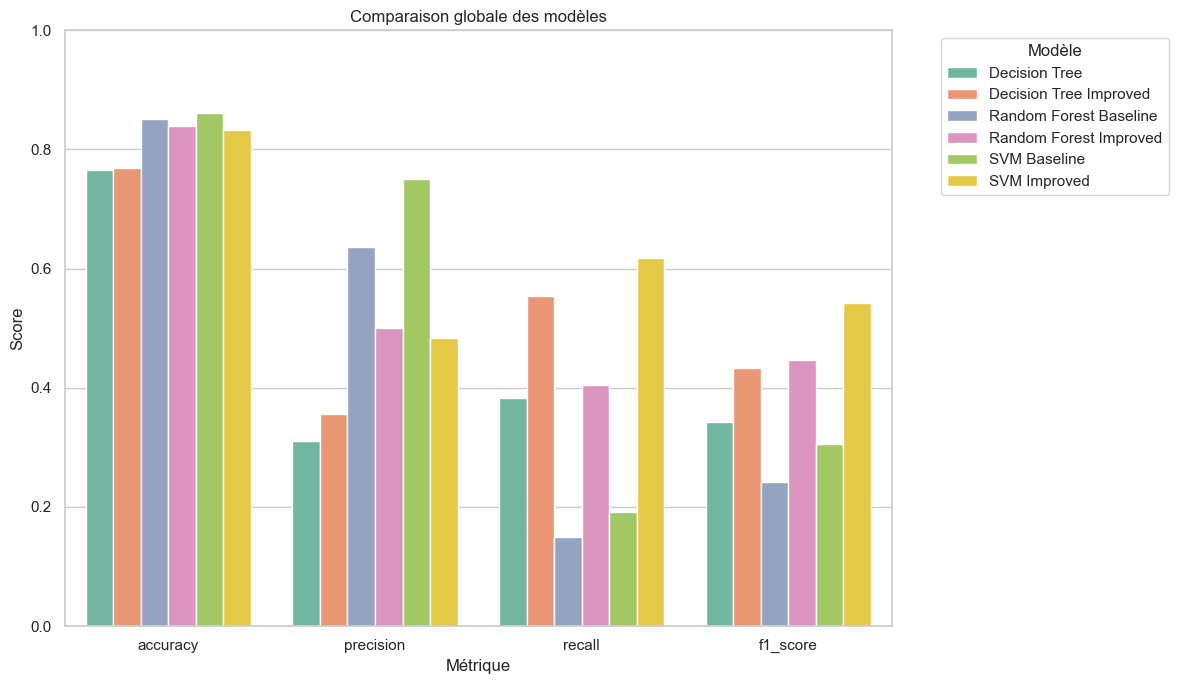

In [25]:
figures_dir = "../results/figures"
os.makedirs(figures_dir, exist_ok=True)

comparison_long = comparison_df.melt(
    id_vars="model",
    value_vars=["accuracy", "precision", "recall", "f1_score"],
    var_name="metric",
    value_name="score",
)

plt.figure(figsize=(12, 7))
sns.barplot(
    data=comparison_long,
    x="metric",
    y="score",
    hue="model",
)
plt.title("Comparaison globale des modèles")
plt.xlabel("Métrique")
plt.ylabel("Score")
plt.ylim(0, 1)
plt.legend(title="Modèle", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.savefig("../results/figures/final_models_comparison.png", dpi=300, bbox_inches="tight")
plt.show()

In [26]:
best_f1_model = comparison_df.loc[comparison_df["f1_score"].idxmax(), "model"]
best_recall_model = comparison_df.loc[comparison_df["recall"].idxmax(), "model"]
best_accuracy_model = comparison_df.loc[comparison_df["accuracy"].idxmax(), "model"]

print(f"Meilleur modèle selon le F1-score : {best_f1_model}")
print(f"Meilleur modèle selon le recall : {best_recall_model}")
print(f"Meilleur modèle selon l'accuracy : {best_accuracy_model}")

Meilleur modèle selon le F1-score : SVM Improved
Meilleur modèle selon le recall : SVM Improved
Meilleur modèle selon l'accuracy : SVM Baseline


**Interprétation :** On remarque que le graphique compare tous les modèles selon quatre métriques : accuracy, precision, recall et F1-score.

Le modèle avec la meilleure accuracy est SVM Baseline, avec une accuracy d’environ 86 %.
Cela veut dire qu’il fait le plus grand nombre de bonnes prédictions globales.

Mais dans notre projet, l’accuracy seule ne suffit pas pour choisir le meilleur modèle.
Le dataset est déséquilibré, car il y a plus d’employés qui restent que d’employés qui quittent l’entreprise.
Donc un modèle peut avoir une bonne accuracy même s’il détecte mal les employés en attrition.

On remarque que le meilleur modèle selon le recall est SVM Improved.
Cela signifie que ce modèle détecte le plus d’employés qui ont réellement quitté l’entreprise.
C’est très important dans notre projet, car l’objectif principal est de prédire les employés qui risquent de quitter l’entreprise.

On remarque aussi que le meilleur modèle selon le F1-score est également SVM Improved.
Cela montre que ce modèle donne le meilleur équilibre entre la précision et le recall.

Les modèles améliorés donnent généralement de meilleurs résultats pour la classe Attrition = Yes.
Même si certains modèles baseline ont une meilleure accuracy ou une meilleure précision, ils ratent beaucoup d’employés à risque.

**Conclusion partielle :**

Donc, on peut conclure que SVM Improved est le meilleur modèle pour ce projet.
Il n’a pas la meilleure accuracy, mais il obtient le meilleur recall et le meilleur F1-score.
Cela signifie qu’il est le plus adapté pour détecter les employés qui risquent de quitter l’entreprise.

## 7. Comparaison du recall

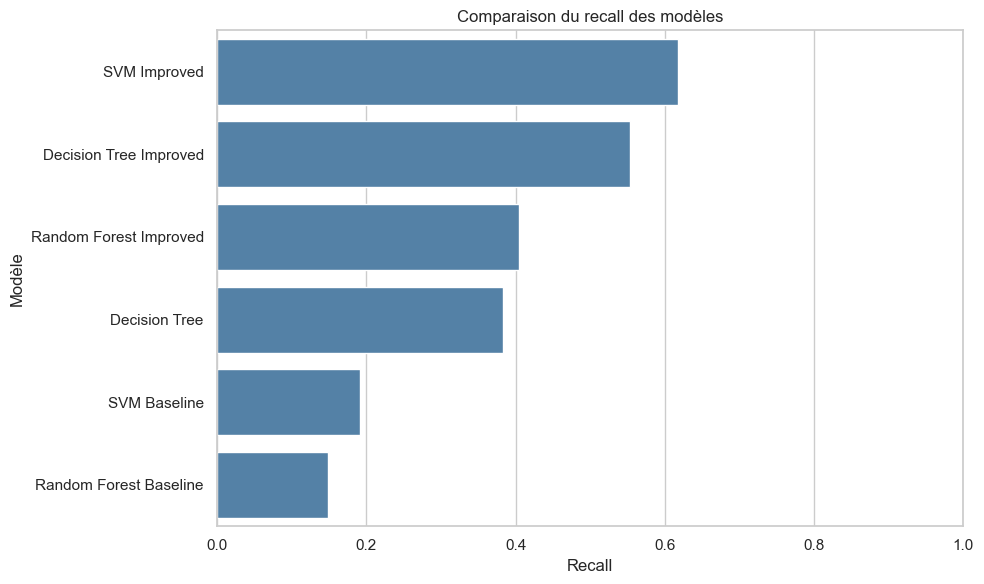

In [27]:
plt.figure(figsize=(10, 6))
sns.barplot(
    data=comparison_by_recall,
    x="recall",
    y="model",
    color="steelblue",
)
plt.title("Comparaison du recall des modèles")
plt.xlabel("Recall")
plt.ylabel("Modèle")
plt.xlim(0, 1)
plt.tight_layout()
plt.savefig("../results/figures/final_recall_comparison.png", dpi=300, bbox_inches="tight")
plt.show()

**Interprétation :** On remarque que ce graphique compare les modèles selon le recall.

Le meilleur modèle est SVM Improved, avec le recall le plus élevé.
Cela signifie qu’il détecte le plus grand nombre d’employés qui ont réellement quitté l’entreprise.

En deuxième position, on trouve Decision Tree Improved.
Ce modèle détecte aussi une bonne partie des employés en attrition, mais il reste moins performant que le SVM Improved.

Ensuite, on trouve Random Forest Improved et Decision Tree.
Leur recall est moyen, donc ils détectent une partie des employés à risque, mais ils en ratent encore plusieurs.

Les modèles SVM Baseline et Random Forest Baseline ont les recalls les plus faibles.
Cela signifie qu’ils détectent très peu les employés qui quittent réellement l’entreprise.

Cette observation est importante parce que, dans notre projet, le recall est une métrique très importante.
L’objectif principal est de prédire les employés qui risquent de quitter l’entreprise.
Donc, un modèle avec un recall élevé est plus intéressant, même si son accuracy n’est pas la meilleure.

**Conclusion partielle :**

Donc, on peut conclure que SVM Improved est le meilleur modèle selon le recall.
Il est le plus adapté pour détecter les employés qui risquent réellement de quitter l’entreprise.

## 8. Comparaison du F1-score

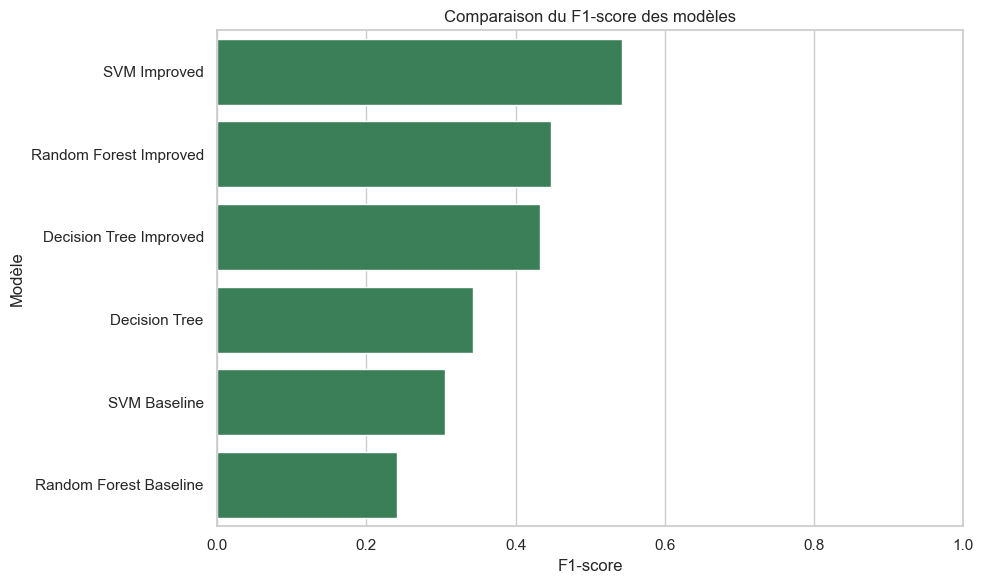

In [28]:
plt.figure(figsize=(10, 6))
sns.barplot(
    data=comparison_by_f1,
    x="f1_score",
    y="model",
    color="seagreen",
)
plt.title("Comparaison du F1-score des modèles")
plt.xlabel("F1-score")
plt.ylabel("Modèle")
plt.xlim(0, 1)
plt.tight_layout()
plt.savefig("../results/figures/final_f1_score_comparison.png", dpi=300, bbox_inches="tight")
plt.show()

**Interprétation :** On remarque que ce graphique compare les modèles selon le F1-score.

Le modèle avec le meilleur F1-score est SVM Improved.
Cela signifie que ce modèle donne le meilleur équilibre entre la precision et le recall.

En deuxième position, on trouve Random Forest Improved.
Ce modèle donne aussi un résultat intéressant, mais il reste moins performant que le SVM Improved.

Ensuite, on trouve Decision Tree Improved.
Son F1-score est proche de celui du Random Forest Improved, ce qui montre que l’amélioration du Decision Tree a bien aidé le modèle.

On remarque aussi que les modèles améliorés sont mieux classés que les modèles baseline.
Cela montre que les techniques d’amélioration ont permis de mieux détecter la classe Attrition = Yes.

Les modèles SVM Baseline et Random Forest Baseline ont des F1-scores plus faibles.
Même s’ils ont une bonne accuracy, ils ne sont pas les meilleurs pour détecter les employés qui risquent de quitter l’entreprise.

**Conclusion partielle :**

Donc, on peut conclure que SVM Improved est le meilleur modèle selon le F1-score.
Il est le plus équilibré pour prédire les employés qui risquent de quitter l’entreprise.

## 9. Sélection du meilleur modèle

In [29]:
best_models_summary = pd.DataFrame(
    {
        "critère": ["accuracy", "recall", "f1_score"],
        "meilleur_modèle": [best_accuracy_model, best_recall_model, best_f1_model],
        "score": [
            comparison_df["accuracy"].max(),
            comparison_df["recall"].max(),
            comparison_df["f1_score"].max(),
        ],
    }
)

best_models_summary

,critère,meilleur_modèle,score
0,accuracy,SVM Baseline,0.860544
1,recall,SVM Improved,0.617021
2,f1_score,SVM Improved,0.542056


**Interprétation :** Le meilleur modèle final ne doit pas être choisi uniquement selon l'accuracy, car la classe **Attrition = Yes** est minoritaire. Un modèle peut avoir une bonne accuracy en prédisant surtout la classe majoritaire `No`, mais être moins utile pour détecter les vrais départs.

## 10. Décision finale

In [30]:
selected_model = best_f1_model
selected_model_metrics = comparison_df[comparison_df["model"] == selected_model]
selected_model_metrics

,model,accuracy,precision,recall,f1_score
5,SVM Improved,0.833333,0.483333,0.617021,0.542056


**Décision :** On remarque que le modèle choisi pour la décision finale est SVM Improved.

Ce modèle obtient une accuracy de 0,8333, soit environ 83,33 %.
Cela veut dire qu’il prédit correctement une grande partie des employés.

La précision est de 0,4833.
Cela signifie que, parmi les employés prédits comme risquant de quitter l’entreprise, presque la moitié ont réellement quitté l’entreprise.

Le recall est de 0,6170, soit environ 61,70 %.
C’est le point le plus important dans ce projet.
Cela signifie que le modèle arrive à détecter plus de la moitié des employés qui ont réellement quitté l’entreprise.

Le F1-score est de 0,5421.
Ce score montre que le modèle donne le meilleur équilibre entre la précision et le recall par rapport aux autres modèles testés.

Même si SVM Improved n’a pas la meilleure accuracy, il est le plus utile pour détecter les employés qui risquent de quitter l’entreprise.

**Conclusion partielle :**

Donc, on peut conclure que SVM Improved est le modèle final choisi pour ce projet.
Il est le plus adapté car il obtient le meilleur recall et le meilleur F1-score, ce qui permet de mieux identifier les employés à risque.

## 11. Recommandation métier

Le modèle ne remplace pas la décision humaine. Il doit être utilisé comme un outil d'aide à la décision pour aider le service RH à prioriser les employés à surveiller ou à accompagner.

Quelques actions possibles :

- organiser une discussion avec l'employé ;
- améliorer les conditions de travail si nécessaire ;
- analyser la charge de travail et les heures supplémentaires ;
- suivre la satisfaction au travail ;
- proposer un accompagnement professionnel ou une évolution de carrière.

## 12. Limites

Ce projet présente plusieurs limites :

- le dataset est limité et ne représente pas forcément toutes les situations RH réelles ;
- les classes sont déséquilibrées, avec moins d'employés dans la classe **Attrition = Yes** ;
- les résultats dépendent fortement du dataset utilisé ;
- le modèle ne doit pas être utilisé comme une décision automatique réelle ;
- une validation avec des données réelles plus récentes serait nécessaire avant toute utilisation opérationnelle.

## Conclusion générale

Ce projet nous a permis d'appliquer un pipeline complet de Machine Learning supervisé : chargement du dataset, analyse exploratoire, nettoyage, encodage, séparation train/test, entraînement de plusieurs modèles, évaluation, comparaison et décision finale.

La comparaison finale montre l'importance d'utiliser plusieurs métriques, surtout dans un problème déséquilibré comme la prédiction de l'attrition. L'accuracy seule n'est pas suffisante : le recall et le F1-score sont essentiels pour évaluer la capacité du modèle à détecter les employés qui risquent réellement de quitter l'entreprise.